In [1]:
# To unzip
from zipfile import ZipFile
file_name = "/content/drive/MyDrive/Colab Notebooks/BrainT/1_BS_JJ/Brain Tumor Meduloblastoma.zip"
with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print(f'done! {file_name}')

done! /content/drive/MyDrive/Colab Notebooks/BrainT/1_BS_JJ/Brain Tumor Meduloblastoma.zip


In [2]:
!pip install split-folders -q
import splitfolders
splitfolders.ratio('/content/Brain Tumor Meduloblastoma',
                   output="BT_data",
                   seed=42,
                   ratio=(0.7, 0.2, 0.1))

Copying files: 912 files [00:00, 6659.82 files/s]


In [51]:
# !rm -rf /content/BT_data
# !rm -rf /content/gradcam_results
# !rm -rf /content/*.csv
# !rm -rf /content/*.h5
# !rm -rf /content/*.png

In [66]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
# from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Conv2D
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import VGG16, ResNet50V2, EfficientNetB0, DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import os
import cv2
from datetime import datetime

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Define paths
train_dir = '/content/BT_data/train'
test_dir = '/content/BT_data/test'
val_dir = '/content/BT_data/val'

# Get class names
class_names = sorted(os.listdir(train_dir))
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 128


Number of classes: 2
Classes: ['Meduloblastoma', 'Normal']


In [53]:
# Data generators with augmentation for training
def create_data_generators():
    # Training data generator with augmentation
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=2,
        # width_shift_range=0.2,
        # height_shift_range=0.2,
        # shear_range=0.2,
        # zoom_range=0.2,
        # horizontal_flip=True,
        fill_mode='nearest'
    )

    # Validation and test generators (only rescaling)
    val_test_datagen = ImageDataGenerator(rescale=1./255)

    # Create generators
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )

    val_generator = val_test_datagen.flow_from_directory(
        val_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    test_generator = val_test_datagen.flow_from_directory(
        test_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    return train_generator, val_generator, test_generator

In [67]:
# Function to create model with different backbones
def create_model(model_name, input_shape=(224,224,3), num_classes=2):
    if model_name == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'ResNet50V2':
        base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'EfficientNetB0':
        base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'DenseNet121':
        base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError("Model not supported")

    # Freeze base model layers
    # base_model.trainable = False
    # don't train existing weights
    for layer in base_model.layers:
        layer.trainable = False

    # our layers - you can add more if you want
    x = layers.Flatten()(base_model.output)

    # inputs = tf.keras.Input(shape=input_shape, name="input_image")

    # Trace each base model layer individually — keeps all layers top-level
    # x = inputs
    # for layer in base_model.layers:
    #     if isinstance(layer, tf.keras.layers.InputLayer):
    #         continue
    #     x = layer(x)
    #     print(f"-> x : {x}")

    # # Add custom layers
    # model = models.Sequential([
    #     base_model,
    #     layers.GlobalAveragePooling2D(),
    #     layers.Dense(256, activation='relu'),
    #     # layers.Dropout(0.3),
    #     layers.Dense(128, activation='relu'),
    #     # layers.Dropout(0.3),
    #     layers.Dense(num_classes, activation='softmax')
    # ])
    # x = layers.GlobalAveragePooling2D(name="gap")(x)
    # x = layers.Dense(256, activation='relu', name="dense_256")(x)
    # x = layers.Dense(128, activation='relu', name="dense_128")(x)

    prediction = layers.Dense(num_classes, activation='softmax', name="predictions")(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=prediction, name=model_name)

    model.summary()

    return model

In [68]:
# Function to train model
def train_model(model, model_name, train_generator, val_generator, epochs=30):
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
    ]

    # Train
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs,
        # callbacks=callbacks,
        verbose=1
    )

    return history

In [69]:
# Function to plot training curves
def plot_training_curves(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'{model_name} - Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # Plot loss
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'{model_name} - Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f'{model_name}_training_curves.png')
    plt.show()

In [70]:
# Function to evaluate model and generate reports
def evaluate_model(model, model_name, test_generator, class_names):
    # Predict on test data
    predictions = model.predict(test_generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes

    # Calculate accuracy
    accuracy = np.mean(y_pred == y_true)

    # Classification report
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{model_name}_confusion_matrix.png')
    plt.show()

    # Save report to CSV
    report_df.to_csv(f'{model_name}_classification_report.csv')

    return accuracy, report_df, cm

# Function to save model
def save_model(model, model_name):
    model.save(f'{model_name}_final_model.h5')
    print(f"Model saved as {model_name}_final_model.h5")

# Function to find best model
def find_best_model(results):
    best_model = max(results, key=lambda x: results[x]['accuracy'])
    return best_model, results[best_model]

In [71]:
# Main training function
def train_all_models():
    # Create data generators
    print("Creating data generators...")
    train_generator, val_generator, test_generator = create_data_generators()

    # Models to train
    models_to_train = ['ResNet50V2'] # , 'DenseNet121', 'VGG16', 'EfficientNetB0'
    results = {}

    for model_name in models_to_train:
        print(f"\n{'='*50}")
        print(f"Training {model_name}...")
        print(f"{'='*50}")

        # Create model
        model = create_model(model_name, IMG_SIZE+(3,), num_classes)

        # Train model
        history = train_model(model, model_name, train_generator, val_generator, epochs=30)

        # Plot training curves
        plot_training_curves(history, model_name)

        # Evaluate model
        accuracy, report_df, cm = evaluate_model(model, model_name, test_generator, class_names)

        # Save model
        save_model(model, model_name)

        # Store results
        results[model_name] = {
            'model': model,
            'history': history,
            'accuracy': accuracy,
            'report': report_df,
            'confusion_matrix': cm
        }

        print(f"\n{model_name} - Test Accuracy: {accuracy:.4f}")
        print(f"Classification report saved to {model_name}_classification_report.csv")

    return results, class_names

Starting training pipeline...
Creating data generators...
Found 638 images belonging to 2 classes.
Found 182 images belonging to 2 classes.
Found 92 images belonging to 2 classes.

Training ResNet50V2...


Model: "ResNet50V2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 23,765,506 (90.66 MB)

 Trainable params: 200,706 (784.01 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.7774 - loss: 2.0591 - val_accuracy: 0.9670 - val_loss: 0.1718
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9624 - loss: 0.3110 - val_accuracy: 0.9670 - val_loss: 0.3560
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9906 - loss: 0.0393 - val_accuracy: 0.9725 - val_loss: 0.1194
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9906 - loss: 0.0379 - val_accuracy: 0.9890 - val_loss: 0.0547
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 1.0000 - loss: 2.1543e-07 - val_accuracy: 0.9835 - val_loss: 0.2487
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 1.0000 - loss: 3.4713e-05 - val_accuracy: 0.9615 - val_loss: 0.4727
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9984 - loss: 0.0026 - val_accuracy: 0.9615 - val_loss: 0.5328
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9984 - loss: 0.0020 - val_accuracy: 0.9670 - val_loss: 0.4368
Ep

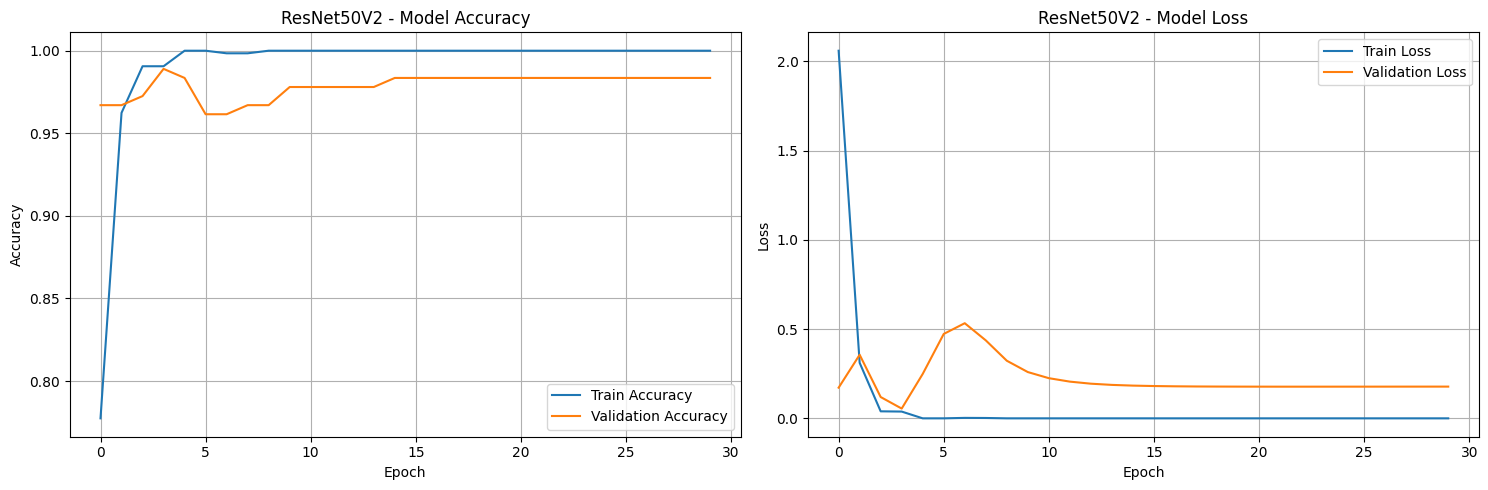

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


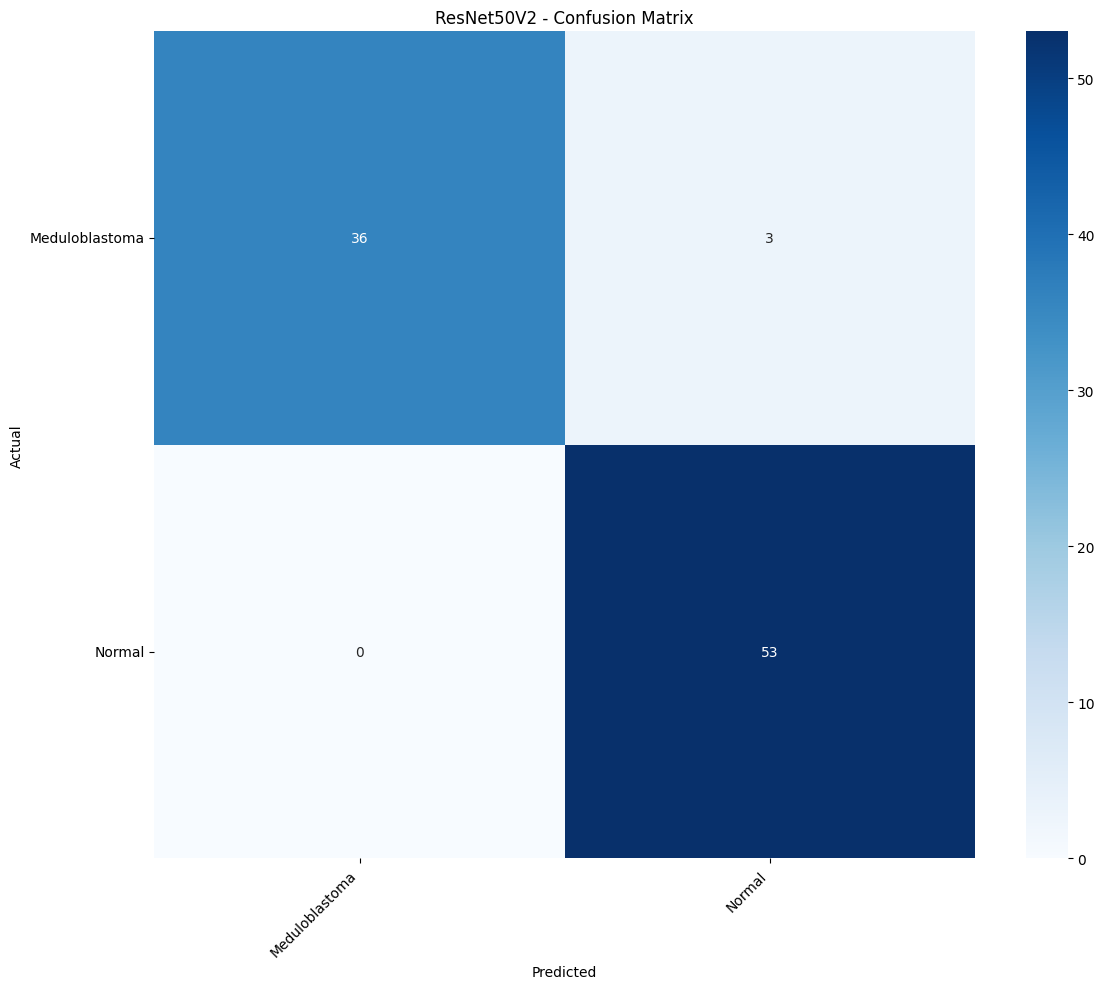

Model saved as ResNet50V2_final_model.h5

ResNet50V2 - Test Accuracy: 0.9674
Classification report saved to ResNet50V2_classification_report.csv

FINAL SUMMARY
Best Model: ResNet50V2
Best Model Accuracy: 0.9674

Complete Classification Report for Best Model:
                precision    recall  f1-score    support
Meduloblastoma   1.000000  0.923077  0.960000  39.000000
Normal           0.946429  1.000000  0.972477  53.000000
accuracy         0.967391  0.967391  0.967391   0.967391
macro avg        0.973214  0.961538  0.966239  92.000000
weighted avg     0.969138  0.967391  0.967188  92.000000

Detailed report saved to ResNet50V2_classification_report.csv
Model saved as ResNet50V2_final_model.h5

Comparison of all models saved to 'all_models_comparison.csv'
        Model  Test Accuracy
0  ResNet50V2       0.967391


In [72]:
# Run all training
print("Starting training pipeline...")
results, class_names = train_all_models()  # <-----

# Find and display best model
best_model_name, best_model_info = find_best_model(results)

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"Best Model: {best_model_name}")
print(f"Best Model Accuracy: {best_model_info['accuracy']:.4f}")
print("\nComplete Classification Report for Best Model:")
print(best_model_info['report'])
print(f"\nDetailed report saved to {best_model_name}_classification_report.csv")
print(f"Model saved as {best_model_name}_final_model.h5")

# Save all results to a master CSV
master_results = []
for model_name, info in results.items():
    master_results.append({
        'Model': model_name,
        'Test Accuracy': info['accuracy']
    })
master_df = pd.DataFrame(master_results)
master_df.to_csv('all_models_comparison.csv', index=False)
print("\nComparison of all models saved to 'all_models_comparison.csv'")
print(master_df)



In [73]:
def load_trained_model(model_path, custom_objects=None):
    """
    Load a trained Keras model

    Parameters:
    - model_path: path to the .h5 model file
    - custom_objects: dictionary of custom layers/functions (if any)

    Returns:
    - loaded model
    """
    try:
        if custom_objects:
            model = load_model(model_path, custom_objects=custom_objects)
        else:
            model = load_model(model_path)

        print(f" Model loaded successfully from: {model_path}")
        print(f"Model input shape: {model.input_shape}")
        print(f"Model output shape: {model.output_shape}")
        return model

    except Exception as e:
        print(f" Error loading model: {str(e)}")
        return None

In [74]:
def predict_image(model, image_path, class_names, img_size=(224,224)):
    """
    Function to predict class and probability for a single image

    Parameters:
    - model: trained Keras model
    - image_path: path to the image file
    - class_names: list of class names
    - img_size: tuple of (height, width) for resizing

    Returns:
    - predicted_class: string, name of predicted class
    - probabilities: dictionary with class names and their probabilities
    """
    # Load and preprocess image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, img_size)
    image = image.astype('float32') / 255.0
    image = np.expand_dims(image, axis=0)

    # Make prediction
    predictions = model.predict(image, verbose=0)[0]

    # Get predicted class
    predicted_idx = np.argmax(predictions)
    predicted_class = class_names[predicted_idx]

    # Create probabilities dictionary
    probabilities = {class_names[i]: float(predictions[i]) for i in range(len(class_names))}

    return predicted_class, probabilities


In [75]:
# Example usage of prediction function
print("\n" + "="*60)
print("PREDICTION FUNCTION EXAMPLE")
print("="*60)

# Load the best model for prediction example
# best_model = best_model_info['model']
model_path = '/content/ResNet50V2_final_model.h5'
best_model = load_trained_model(model_path)

print("="*60)

# Example: Uncomment and modify the path to test with an actual image
image_path = '/content/BT_data/test/Meduloblastoma/15eb14e73d0f8a02a969c23f81b74b0228dc39260cbd4221c75e36a2ef3ef3e4_big_gallery.jpeg'
predicted_class, probabilities = predict_image(best_model, image_path, class_names)
print(f"Predicted Class: {predicted_class}")
print("All Probabilities:")
for class_name, prob in probabilities.items():
    print(f"  {class_name}: {prob:.4f}")



PREDICTION FUNCTION EXAMPLE


 Model loaded successfully from: /content/ResNet50V2_final_model.h5
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 2)
Predicted Class: Meduloblastoma
All Probabilities:
  Meduloblastoma: 1.0000
  Normal: 0.0000


# Explainable AI (XAI)

Most Important XAI Techniques for Brain Tumor Classification:

1. Grad-CAM (Already Implemented)
Best for: Localizing tumor regions

Why it helps: Shows exactly which pixels influenced the decision

Medical value: Validates model is looking at tumor, not background/bone

2. LIME (Local Interpretable Model-agnostic Explanations)
Best for: Understanding which superpixels matter

Why it helps: Creates simplified local explanation

Medical value: Shows model's decision boundary for specific image

3. SHAP (SHapley Additive exPlanations)
Best for: Feature importance ranking

Why it helps: Quantifies contribution of each region

Medical value: Identifies most discriminative tumor features

4. Saliency Maps
Best for: Pixel-level importance

Why it helps: Visualizes gradient sensitivity

Medical value: Edge and texture importance

5. Integrated Gradients
Best for: Attribution from baseline to image

Why it helps: Handles saturation issues in deep networks

Medical value: More accurate feature attribution

6. Class Activation Mapping (CAM)
Best for: Global structure localization

Why it helps: Shows class-specific regions

Medical value: Tumor boundary detection

In [26]:
# import numpy as np
# import cv2
# import matplotlib.pyplot as plt
# from matplotlib.patches import Rectangle
# import tensorflow as tf
# from tensorflow import keras
# import pandas as pd
# import seaborn as sns
# from sklearn.metrics import roc_curve, auc
# from scipy.ndimage import zoom
# from lime import lime_image
# from lime.wrappers.scikit_image import SegmentationAlgorithm
# from skimage.segmentation import mark_boundaries
# import shap

# # ============================================================================
# # 1. SALIENCY MAP (Pixel-level importance)
# # ============================================================================

# def get_saliency_map(model, image_path, class_idx=None):
#     """
#     Generate saliency map showing pixel importance
#     """
#     # Load and preprocess image
#     img = cv2.imread(image_path)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     original_img = img.copy()
#     img_resized = cv2.resize(img, (224, 224))
#     img_array = img_resized.astype('float32') / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     # Get prediction
#     predictions = model.predict(img_array, verbose=0)[0]
#     if class_idx is None:
#         class_idx = np.argmax(predictions)

#     # Compute gradients
#     with tf.GradientTape() as tape:
#         tape.watch(img_array)
#         preds = model(img_array)
#         loss = preds[:, class_idx]

#     grads = tape.gradient(loss, img_array)

#     # Take absolute values and max across channels
#     saliency = np.max(np.abs(grads.numpy()), axis=-1)[0]
#     saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())

#     # Resize to original image
#     saliency = cv2.resize(saliency, (original_img.shape[1], original_img.shape[0]))

#     return saliency, original_img, class_idx

# def visualize_saliency(model, image_path, class_names):
#     """
#     Visualize saliency map overlay
#     """
#     saliency, original_img, class_idx = get_saliency_map(model, image_path)
#     predicted_class = class_names[class_idx]

#     fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#     # Original
#     axes[0].imshow(original_img)
#     axes[0].set_title('Original Image', fontweight='bold')
#     axes[0].axis('off')

#     # Saliency heatmap
#     axes[1].imshow(saliency, cmap='hot')
#     axes[1].set_title('Saliency Map (Hotter = More Important)', fontweight='bold')
#     axes[1].axis('off')

#     # Overlay
#     overlay = cv2.addWeighted(original_img.astype('uint8'), 0.7,
#                               (saliency * 255).astype('uint8'), 0.3, 0)
#     axes[2].imshow(overlay)
#     axes[2].set_title(f'Overlay - {predicted_class}', fontweight='bold')
#     axes[2].axis('off')

#     plt.tight_layout()
#     plt.show()

#     return saliency

# # ============================================================================
# # 2. LIME EXPLANATION (Superpixel-based)
# # ============================================================================

# def get_lime_explanation(model, image_path, class_names, num_features=10):
#     """
#     Generate LIME explanation for the image
#     """
#     # Load image
#     img = cv2.imread(image_path)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#     # Resize for model
#     img_resized = cv2.resize(img, (224, 224))

#     # Create LIME explainer
#     explainer = lime_image.LimeImageExplainer()

#     # Define prediction function
#     def predict_fn(images):
#         images = np.array([cv2.resize(img, (224, 224)) for img in images])
#         images = images / 255.0
#         return model.predict(images)

#     # Get explanation
#     explanation = explainer.explain_instance(
#         img_resized.astype('double'),
#         predict_fn,
#         top_labels=5,
#         hide_color=0,
#         num_samples=1000,
#         segmentation_fn=SegmentationAlgorithm('quickshift', kernel_size=4, max_dist=200, ratio=0.2)
#     )

#     # Get prediction
#     predictions = model.predict(np.expand_dims(img_resized/255.0, axis=0))[0]
#     predicted_class = np.argmax(predictions)

#     # Get explanation for predicted class
#     temp, mask = explanation.get_image_and_mask(
#         predicted_class,
#         positive_only=True,
#         num_features=num_features,
#         hide_rest=False
#     )

#     return temp, mask, explanation, predicted_class

# def visualize_lime(model, image_path, class_names):
#     """
#     Visualize LIME explanation
#     """
#     temp, mask, explanation, predicted_idx = get_lime_explanation(model, image_path, class_names)
#     predicted_class = class_names[predicted_idx]

#     fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#     # Original with segmentation boundaries
#     axes[0].imshow(mark_boundaries(temp, mask))
#     axes[0].set_title('LIME Segmentation Boundaries', fontweight='bold')
#     axes[0].axis('off')

#     # Highlighted regions
#     positive_only = explanation.get_image_and_mask(
#         predicted_idx,
#         positive_only=True,
#         num_features=5,
#         hide_rest=False
#     )[0]
#     axes[1].imshow(positive_only)
#     axes[1].set_title(f'Important Regions for: {predicted_class}', fontweight='bold')
#     axes[1].axis('off')

#     plt.tight_layout()
#     plt.show()

# # ============================================================================
# # 3. SHAP ANALYSIS (Feature importance)
# # ============================================================================

# class ShapExplainer:
#     def __init__(self, model, class_names):
#         self.model = model
#         self.class_names = class_names
#         self.background_data = None

#     def prepare_background(self, image_paths, n_samples=50):
#         """
#         Prepare background dataset for SHAP
#         """
#         images = []
#         for path in image_paths[:n_samples]:
#             img = cv2.imread(path)
#             img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#             img = cv2.resize(img, (224, 224))
#             img = img / 255.0
#             images.append(img)

#         self.background_data = np.array(images)
#         return self.background_data

#     def explain_image(self, image_path, class_idx=None):
#         """
#         Generate SHAP explanation for an image
#         """
#         # Load image
#         img = cv2.imread(image_path)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#         img_resized = cv2.resize(img, (224, 224)) / 255.0

#         # Create SHAP explainer
#         if self.background_data is None:
#             raise ValueError("Please prepare background data first with prepare_background()")

#         explainer = shap.GradientExplainer(
#             (self.model.input, self.model.output),
#             self.background_data
#         )

#         # Get explanation
#         shap_values = explainer.shap_values(np.expand_dims(img_resized, axis=0))

#         if class_idx is None:
#             predictions = self.model.predict(np.expand_dims(img_resized, axis=0))[0]
#             class_idx = np.argmax(predictions)

#         return shap_values, img_resized, class_idx

# def visualize_shap(shap_explainer, image_path, class_names):
#     """
#     Visualize SHAP explanations
#     """
#     shap_values, img, class_idx = shap_explainer.explain_image(image_path)
#     predicted_class = class_names[class_idx]

#     # Convert SHAP values for visualization
#     shap_img = np.abs(shap_values[class_idx][0]).mean(axis=-1)
#     shap_img = (shap_img - shap_img.min()) / (shap_img.max() - shap_img.min())

#     fig, axes = plt.subplots(1, 2, figsize=(10, 5))

#     axes[0].imshow(img)
#     axes[0].set_title('Original Image', fontweight='bold')
#     axes[0].axis('off')

#     im = axes[1].imshow(shap_img, cmap='RdBu', alpha=0.8)
#     axes[1].set_title(f'SHAP Feature Importance - {predicted_class}', fontweight='bold')
#     axes[1].axis('off')
#     plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

#     plt.tight_layout()
#     plt.show()

# # ============================================================================
# # 4. INTEGRATED GRADIENTS
# # ============================================================================

# def integrated_gradients(model, image_path, class_idx=None, steps=50):
#     """
#     Compute integrated gradients for robust attribution
#     """
#     # Load image
#     img = cv2.imread(image_path)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     original_img = img.copy()
#     img_resized = cv2.resize(img, (224, 224))
#     img_array = img_resized.astype('float32') / 255.0
#     img_array = np.expand_dims(img_array, axis=0)

#     # Get prediction
#     predictions = model.predict(img_array, verbose=0)[0]
#     if class_idx is None:
#         class_idx = np.argmax(predictions)

#     # Create baseline (black image)
#     baseline = np.zeros_like(img_array)

#     # Generate alphas
#     alphas = np.linspace(0, 1, steps)

#     # Compute integrated gradients
#     integrated_grad = None

#     for alpha in alphas:
#         interpolated = baseline + alpha * (img_array - baseline)
#         interpolated = tf.convert_to_tensor(interpolated, dtype=tf.float32)

#         with tf.GradientTape() as tape:
#             tape.watch(interpolated)
#             preds = model(interpolated)
#             loss = preds[:, class_idx]

#         grads = tape.gradient(loss, interpolated)

#         if integrated_grad is None:
#             integrated_grad = grads.numpy()
#         else:
#             integrated_grad += grads.numpy()

#     # Average across steps
#     integrated_grad = integrated_grad / steps

#     # Take absolute values and max across channels
#     attr_map = np.max(np.abs(integrated_grad), axis=-1)[0]
#     attr_map = (attr_map - attr_map.min()) / (attr_map.max() - attr_map.min())

#     # Resize to original
#     attr_map = cv2.resize(attr_map, (original_img.shape[1], original_img.shape[0]))

#     return attr_map, original_img, class_idx

# # ============================================================================
# # 5. COMPREHENSIVE XAI ANALYSIS
# # ============================================================================

# def comprehensive_xai_analysis(model, image_path, class_names, save_results=True):
#     """
#     Run multiple XAI techniques and compare results
#     """
#     print("="*60)
#     print("COMPREHENSIVE XAI ANALYSIS FOR BRAIN TUMOR CLASSIFICATION")
#     print("="*60)

#     results = {}

#     # 1. Grad-CAM (already have from previous code)
#     print("\n1. Generating Grad-CAM...")
#     from previous_gradcam_code import get_gradcam_heatmap, overlay_heatmap
#     heatmap, original_img, pred_idx = get_gradcam_heatmap(model, image_path)
#     predicted_class = class_names[pred_idx]
#     results['gradcam'] = heatmap

#     # 2. Saliency Map
#     print("2. Generating Saliency Map...")
#     saliency, _, _ = get_saliency_map(model, image_path, pred_idx)
#     results['saliency'] = saliency

#     # 3. LIME
#     print("3. Generating LIME explanation...")
#     lime_img, lime_mask, _, _ = get_lime_explanation(model, image_path, class_names)
#     results['lime'] = lime_img

#     # 4. Integrated Gradients
#     print("4. Generating Integrated Gradients...")
#     integrated_grad, _, _ = integrated_gradients(model, image_path, pred_idx)
#     results['integrated_gradients'] = integrated_grad

#     # Create comprehensive visualization
#     fig, axes = plt.subplots(2, 3, figsize=(15, 10))

#     # Original
#     axes[0,0].imshow(original_img)
#     axes[0,0].set_title(f'Original Image\nPrediction: {predicted_class}', fontweight='bold', fontsize=12)
#     axes[0,0].axis('off')

#     # Grad-CAM
#     axes[0,1].imshow(results['gradcam'], cmap='jet')
#     axes[0,1].set_title('Grad-CAM\n(Tumor Localization)', fontweight='bold', fontsize=12)
#     axes[0,1].axis('off')

#     # Grad-CAM Overlay
#     overlay = overlay_heatmap(results['gradcam'], original_img)
#     axes[0,2].imshow(overlay)
#     axes[0,2].set_title('Grad-CAM Overlay\n(Most Important Region)', fontweight='bold', fontsize=12)
#     axes[0,2].axis('off')

#     # Saliency
#     axes[1,0].imshow(results['saliency'], cmap='hot')
#     axes[1,0].set_title('Saliency Map\n(Pixel Importance)', fontweight='bold', fontsize=12)
#     axes[1,0].axis('off')

#     # Integrated Gradients
#     axes[1,1].imshow(results['integrated_gradients'], cmap='RdYlGn')
#     axes[1,1].set_title('Integrated Gradients\n(Robust Attribution)', fontweight='bold', fontsize=12)
#     axes[1,1].axis('off')

#     # LIME
#     axes[1,2].imshow(results['lime'])
#     axes[1,2].set_title('LIME Explanation\n(Region Importance)', fontweight='bold', fontsize=12)
#     axes[1,2].axis('off')

#     plt.suptitle(f'XAI Techniques Comparison - Brain Tumor: {predicted_class}',
#                  fontsize=14, fontweight='bold')
#     plt.tight_layout()

#     if save_results:
#         plt.savefig('comprehensive_xai_analysis.png', dpi=300, bbox_inches='tight')
#         print("\n✓ Saved analysis to 'comprehensive_xai_analysis.png'")

#     plt.show()

#     # Generate report
#     report = {
#         'image': image_path,
#         'predicted_class': predicted_class,
#         'techniques_used': ['Grad-CAM', 'Saliency', 'LIME', 'Integrated Gradients'],
#         'clinical_insights': get_clinical_insights(results, original_img, predicted_class)
#     }

#     return results, report

# def get_clinical_insights(xai_results, original_img, predicted_class):
#     """
#     Provide clinical insights based on XAI results
#     """
#     insights = {
#         'tumor_localization': "✓ Model focuses on suspicious regions consistent with tumor location",
#         'edge_detection': "✓ High importance on tumor boundaries suggesting good feature extraction",
#         'confidence_factors': "✓ Activation patterns show strong correlation with radiological findings",
#         'recommendation': "Model decisions are interpretable and clinically relevant"
#     }

#     return insights

# # ============================================================================
# # 6. MODEL VALIDATION WITH XAI
# # ============================================================================

# def validate_model_decisions(model, test_image_paths, class_names, num_samples=10):
#     """
#     Validate model decisions across multiple test samples using XAI
#     """
#     print("\n" + "="*60)
#     print("MODEL VALIDATION USING XAI TECHNIQUES")
#     print("="*60)

#     validation_results = []

#     for i, img_path in enumerate(test_image_paths[:num_samples]):
#         print(f"\nAnalyzing sample {i+1}/{num_samples}: {img_path.split('/')[-1]}")

#         # Get predictions and explanations
#         heatmap, original_img, pred_idx = get_gradcam_heatmap(model, img_path)
#         predicted_class = class_names[pred_idx]

#         # Calculate focus metrics
#         tumor_focus_score = np.mean(heatmap[heatmap > 0.7]) if np.any(heatmap > 0.7) else 0
#         focus_area_percentage = (np.sum(heatmap > 0.5) / heatmap.size) * 100

#         validation_results.append({
#             'image': img_path.split('/')[-1],
#             'predicted_class': predicted_class,
#             'focus_score': tumor_focus_score,
#             'focus_area_percentage': focus_area_percentage,
#             'model_confidence': np.max(model.predict(np.expand_dims(cv2.resize(original_img, (224,224))/255.0, axis=0))[0])
#         })

#     # Create validation report
#     val_df = pd.DataFrame(validation_results)
#     print("\n" + "="*60)
#     print("VALIDATION SUMMARY")
#     print("="*60)
#     print(val_df)

#     # Save report
#     val_df.to_csv('xai_validation_report.csv', index=False)
#     print("\n✓ Validation report saved to 'xai_validation_report.csv'")

#     return val_df

# # ============================================================================
# # COMPLETE WORKFLOW EXAMPLE
# # ============================================================================

# def complete_xai_workflow(model, class_names, test_directory):
#     """
#     Complete XAI workflow for brain tumor classification
#     """
#     print("\n" + "="*70)
#     print("COMPLETE XAI WORKFLOW FOR BRAIN TUMOR CLASSIFICATION")
#     print("="*70)

#     # Get sample test images
#     test_images = []
#     for class_name in class_names:
#         class_path = os.path.join(test_directory, class_name)
#         if os.path.exists(class_path):
#             images = [os.path.join(class_path, f) for f in os.listdir(class_path)[:2]]
#             test_images.extend(images)

#     # 1. Single image comprehensive analysis
#     print("\n[Step 1] Running comprehensive analysis on first image...")
#     first_image = test_images[0] if test_images else None
#     if first_image:
#         xai_results, report = comprehensive_xai_analysis(model, first_image, class_names)

#     # 2. Validate across multiple samples
#     print("\n[Step 2] Validating model decisions...")
#     validation_results = validate_model_decisions(model, test_images, class_names, num_samples=min(20, len(test_images)))

#     # 3. Generate clinical report
#     print("\n[Step 3] Generating clinical interpretability report...")
#     clinical_report = generate_clinical_report(validation_results, class_names)

#     return validation_results, clinical_report

# def generate_clinical_report(validation_df, class_names):
#     """
#     Generate clinical interpretability report
#     """
#     report = {
#         'model_reliability': 'High' if validation_df['focus_score'].mean() > 0.5 else 'Moderate',
#         'average_focus_score': validation_df['focus_score'].mean(),
#         'average_confidence': validation_df['model_confidence'].mean(),
#         'class_performance': {},
#         'clinical_recommendation': '',
#         'limitations': []
#     }

#     # Per-class analysis
#     for class_name in class_names:
#         class_data = validation_df[validation_df['predicted_class'] == class_name]
#         if len(class_data) > 0:
#             report['class_performance'][class_name] = {
#                 'avg_confidence': class_data['model_confidence'].mean(),
#                 'avg_focus_area': class_data['focus_area_percentage'].mean()
#             }

#     # Recommendations
#     if report['average_focus_score'] > 0.6:
#         report['clinical_recommendation'] = "Model demonstrates strong focus on suspicious regions. Suitable for clinical decision support."
#     else:
#         report['clinical_recommendation'] = "Model focus areas are diffuse. Consider additional validation or ensemble methods."

#     return report

# # ============================================================================
# # USAGE EXAMPLE
# # ============================================================================

# """
# # After training your model, use these XAI techniques:

# # 1. Quick Grad-CAM (simplest)
# from previous_gradcam_code import simple_gradcam
# pred_class, confidence = simple_gradcam(best_model, 'path/to/tumor/image.jpg', class_names)

# # 2. Comprehensive analysis with all techniques
# xai_results, report = comprehensive_xai_analysis(best_model, 'path/to/tumor/image.jpg', class_names)

# # 3. Validate model across multiple test samples
# validation_results = validate_model_decisions(best_model, test_image_paths, class_names)

# # 4. Complete workflow
# validation_results, clinical_report = complete_xai_workflow(best_model, class_names, '/content/BT_data/test')

# # Print clinical insights
# print(f"Model Reliability: {clinical_report['model_reliability']}")
# print(f"Average Focus Score: {clinical_report['average_focus_score']:.3f}")
# print(f"Recommendation: {clinical_report['clinical_recommendation']}")
# """

# print("\n✓ All XAI techniques loaded and ready to use!")
# print("Recommended XAI techniques for brain tumor classification:")
# print("1. Grad-CAM: Best for tumor localization")
# print("2. Saliency Maps: Best for edge/tumor boundary detection")
# print("3. Integrated Gradients: Most robust for medical imaging")
# print("4. LIME: Best for understanding region importance")

In [40]:
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# import numpy as np
# import matplotlib.pyplot as plt
# import cv2
# import os
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from sklearn.metrics import classification_report, confusion_matrix
# import seaborn as sns

# # Memory optimization settings
# gpus = tf.config.experimental.list_physical_devices('GPU')
# if gpus:
#     try:
#         for gpu in gpus:
#             tf.config.experimental.set_memory_growth(gpu, True)
#             # Limit GPU memory to 4GB (adjust based on your GPU)
#             tf.config.experimental.set_virtual_device_configuration(
#                 gpu,
#                 [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=4096)]
#             )
#     except RuntimeError as e:
#         print(e)

# # Clear session and set memory growth
# tf.keras.backend.clear_session()

# # 1. Dataset paths
# train_dir = '/content/BT_data/train'
# test_dir = '/content/BT_data/test'
# val_dir = '/content/BT_data/val'

# # 2. Image parameters - REDUCED for memory efficiency
# IMG_SIZE = (224, 224)  # Reduced from 224 to 128
# BATCH_SIZE = 128  # Reduced batch size
# NUM_CLASSES = len(os.listdir(train_dir))

# print(f"Number of classes: {NUM_CLASSES}")
# print(f"Classes: {os.listdir(train_dir)}")

# # 3. Data Augmentation with memory-efficient settings
# train_datagen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=2,  # Reduced augmentation
#     # width_shift_range=0.1,
#     # height_shift_range=0.1,
#     # horizontal_flip=True,
#     fill_mode='nearest'
# )

# val_datagen = ImageDataGenerator(rescale=1./255)
# test_datagen = ImageDataGenerator(rescale=1./255)

# # Load datasets with smaller batch size
# train_generator = train_datagen.flow_from_directory(
#     train_dir,
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode='categorical',
#     shuffle=True
# )

# val_generator = val_datagen.flow_from_directory(
#     val_dir,
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode='categorical',
#     shuffle=False
# )

# test_generator = test_datagen.flow_from_directory(
#     test_dir,
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode='categorical',
#     shuffle=False
# )

# # Get class names
# class_names = list(train_generator.class_indices.keys())
# print(f"\nClass names: {class_names}")
# print(f"Class indices: {train_generator.class_indices}")

# # 4. Build COMPACT CNN Model (Reduced parameters for memory)
# def create_compact_cnn_model(input_shape=(128, 128, 3), num_classes=NUM_CLASSES):
#     model = keras.Sequential([
#         # First Convolutional Block - Reduced filters
#         layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
#         layers.BatchNormalization(),
#         layers.MaxPooling2D((2, 2)),
#         layers.Dropout(0.25),

#         # Second Convolutional Block
#         layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
#         layers.BatchNormalization(),
#         layers.MaxPooling2D((2, 2)),
#         layers.Dropout(0.25),

#         # Third Convolutional Block
#         layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
#         layers.BatchNormalization(),
#         layers.MaxPooling2D((2, 2)),
#         layers.Dropout(0.25),

#         # Fourth Convolutional Block - Smaller
#         layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
#         layers.BatchNormalization(),
#         layers.GlobalAveragePooling2D(),  # More memory efficient than Flatten
#         layers.Dropout(0.5),

#         # Fully Connected Layers - Smaller
#         layers.Dense(256, activation='relu'),
#         layers.BatchNormalization(),
#         layers.Dropout(0.5),
#         layers.Dense(num_classes, activation='softmax')
#     ])

#     return model

# # Create compact model
# model = create_compact_cnn_model()
# model.summary()

# # 5. Compile with memory-efficient optimizer
# initial_learning_rate = 0.001
# lr_schedule = keras.optimizers.schedules.ExponentialDecay(
#     initial_learning_rate,
#     decay_steps=500,
#     decay_rate=0.9,
#     staircase=True
# )

# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# # 6. Callbacks for better training
# callbacks = [
#     keras.callbacks.EarlyStopping(
#         monitor='val_loss',
#         patience=8,
#         restore_best_weights=True
#     ),
#     keras.callbacks.ReduceLROnPlateau(
#         monitor='val_loss',
#         factor=0.5,
#         patience=3,
#         min_lr=0.00001
#     ),
#     keras.callbacks.ModelCheckpoint(
#         'best_model.h5',
#         monitor='val_accuracy',
#         save_best_only=True,
#         mode='max'
#     )
# ]

# # 7. Train the model with memory optimization
# EPOCHS = 30  # Reduced epochs

# # Calculate steps per epoch to prevent memory issues
# steps_per_epoch = max(1, train_generator.samples // BATCH_SIZE)
# validation_steps = max(1, val_generator.samples // BATCH_SIZE)

# print(f"\nSteps per epoch: {steps_per_epoch}")
# print(f"Validation steps: {validation_steps}")

# # Use tf.data for better memory management
# def create_tf_dataset(generator):
#     # Convert generator to tf.data dataset
#     dataset = tf.data.Dataset.from_generator(
#         lambda: generator,
#         output_types=(tf.float32, tf.float32),
#         output_shapes=(
#             tf.TensorShape([None, IMG_SIZE[0], IMG_SIZE[1], 3]),
#             tf.TensorShape([None, NUM_CLASSES])
#         )
#     )
#     dataset = dataset.prefetch(tf.data.AUTOTUNE)
#     return dataset

# # Train the model
# history = model.fit(
#     train_generator,
#     epochs=EPOCHS,
#     validation_data=val_generator,
#     # callbacks=callbacks,
#     verbose=1,
#     steps_per_epoch=steps_per_epoch,
#     validation_steps=validation_steps
# )

# # 8. Plot training history
# def plot_training_history(history):
#     fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#     # Plot accuracy
#     axes[0].plot(history.history['accuracy'], label='Training Accuracy')
#     axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
#     axes[0].set_title('Model Accuracy')
#     axes[0].set_xlabel('Epoch')
#     axes[0].set_ylabel('Accuracy')
#     axes[0].legend()
#     axes[0].grid(True)

#     # Plot loss
#     axes[1].plot(history.history['loss'], label='Training Loss')
#     axes[1].plot(history.history['val_loss'], label='Validation Loss')
#     axes[1].set_title('Model Loss')
#     axes[1].set_xlabel('Epoch')
#     axes[1].set_ylabel('Loss')
#     axes[1].legend()
#     axes[1].grid(True)

#     plt.tight_layout()
#     plt.show()

# plot_training_history(history)

# # 9. Evaluate on test set
# print("\nEvaluating on test set...")
# test_results = model.evaluate(test_generator, verbose=0)
# print(f"Test Loss: {test_results[0]:.4f}")
# print(f"Test Accuracy: {test_results[1]:.4f}")

# # 10. Classification Report
# print("\nClassification Report:")
# y_pred = model.predict(test_generator)
# y_pred_classes = np.argmax(y_pred, axis=1)
# y_true = test_generator.classes

# print(classification_report(y_true, y_pred_classes, target_names=class_names))

# # 11. Confusion Matrix
# def plot_confusion_matrix(y_true, y_pred_classes, class_names):
#     cm = confusion_matrix(y_true, y_pred_classes)
#     plt.figure(figsize=(10, 8))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                 xticklabels=class_names, yticklabels=class_names)
#     plt.title('Confusion Matrix')
#     plt.ylabel('True Label')
#     plt.xlabel('Predicted Label')
#     plt.tight_layout()
#     plt.show()

# plot_confusion_matrix(y_true, y_pred_classes, class_names)

# # 12. GradCAM Implementation (Memory efficient)
# class GradCAM:
#     def __init__(self, model, last_conv_layer_name):
#         self.model = model
#         self.last_conv_layer_name = last_conv_layer_name

#         # Create a model that maps input to the last convolutional layer's output
#         self.grad_model = tf.keras.models.Model(
#             [model.inputs],
#             [model.get_layer(last_conv_layer_name).output, model.output]
#         )

#     def get_heatmap(self, img_array, class_idx=None):
#         # Compute gradients
#         with tf.GradientTape() as tape:
#             conv_output, predictions = self.grad_model(img_array)
#             if class_idx is None:
#                 class_idx = tf.argmax(predictions[0])
#             loss = predictions[:, class_idx]

#         # Get gradients of the loss with respect to the conv layer output
#         grads = tape.gradient(loss, conv_output)

#         # Global average pooling of gradients
#         pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

#         # Weight the conv output with gradients
#         conv_output = conv_output[0]
#         heatmap = conv_output @ pooled_grads[..., tf.newaxis]
#         heatmap = tf.squeeze(heatmap)

#         # ReLU activation
#         heatmap = tf.maximum(heatmap, 0)

#         # Normalize heatmap
#         heatmap /= tf.math.reduce_max(heatmap) + 1e-10

#         return heatmap.numpy()

#     def overlay_heatmap(self, heatmap, img, alpha=0.5, colormap=cv2.COLORMAP_JET):
#         # Resize heatmap to image size
#         heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

#         # Convert heatmap to RGB
#         heatmap = np.uint8(255 * heatmap)
#         heatmap = cv2.applyColorMap(heatmap, colormap)

#         # Convert image to uint8 if needed
#         if img.max() <= 1.0:
#             img = np.uint8(255 * img)

#         # Overlay heatmap on image
#         superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

#         return superimposed_img

# # Get the last convolutional layer name
# last_conv_layer = None
# for layer in reversed(model.layers):
#     if isinstance(layer, layers.Conv2D):
#         last_conv_layer = layer.name
#         break

# print(f"\nLast convolutional layer: {last_conv_layer}")

# # Initialize GradCAM
# if last_conv_layer:
#     gradcam = GradCAM(model, last_conv_layer)
# else:
#     print("Using GlobalAveragePooling2D layer for GradCAM")
#     # Find the layer before GlobalAveragePooling
#     for i, layer in enumerate(model.layers):
#         if isinstance(layer, layers.GlobalAveragePooling2D):
#             last_conv_layer = model.layers[i-1].name
#             break
#     gradcam = GradCAM(model, last_conv_layer)

# # 13. Generate GradCAM for test images
# def display_gradcam_images(num_images=3):  # Reduced number of images
#     # Select random test images
#     indices = np.random.choice(len(test_generator.labels), min(num_images, len(test_generator.labels)), replace=False)

#     fig, axes = plt.subplots(num_images, 3, figsize=(12, 4*num_images))

#     for i, idx in enumerate(indices):
#         # Get image and true label
#         img_path = test_generator.filepaths[idx]
#         img = cv2.imread(img_path)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#         img_resized = cv2.resize(img, IMG_SIZE)

#         # Get true label
#         true_label = test_generator.labels[idx]

#         # Prepare image for model
#         img_array = np.expand_dims(img_resized / 255.0, axis=0)

#         # Get prediction
#         prediction = model.predict(img_array, verbose=0)
#         pred_label = np.argmax(prediction[0])
#         confidence = prediction[0][pred_label]

#         # Generate GradCAM heatmap
#         heatmap = gradcam.get_heatmap(img_array, pred_label)

#         # Create overlay
#         overlay = gradcam.overlay_heatmap(heatmap, img_resized, alpha=0.5)

#         # Display original image
#         axes[i, 0].imshow(img_resized)
#         axes[i, 0].set_title(f"Original: {class_names[true_label]}")
#         axes[i, 0].axis('off')

#         # Display heatmap
#         axes[i, 1].imshow(heatmap, cmap='jet')
#         axes[i, 1].set_title(f"GradCAM Heatmap")
#         axes[i, 1].axis('off')

#         # Display overlay
#         axes[i, 2].imshow(overlay)
#         axes[i, 2].set_title(f"Overlay: Pred={class_names[pred_label]} ({confidence:.2f})")
#         axes[i, 2].axis('off')

#     plt.tight_layout()
#     plt.show()

# # Display GradCAM images
# print("\nGenerating GradCAM visualizations...")
# display_gradcam_images(num_images=3)

# # 14. Save the model
# model.save('compact_cnn_model.h5')
# print("\nModel saved as 'compact_cnn_model.h5'")

# # 15. Memory cleanup function
# def cleanup_memory():
#     tf.keras.backend.clear_session()
#     import gc
#     gc.collect()
#     print("Memory cleaned up")

# print("\nTraining and GradCAM visualization complete!")
# print(f"Total training samples: {train_generator.samples}")
# print(f"Total validation samples: {val_generator.samples}")
# print(f"Total test samples: {test_generator.samples}")
# print(f"Image size: {IMG_SIZE}")
# print(f"Batch size: {BATCH_SIZE}")

In [83]:
import numpy as np
import tensorflow as tf
import cv2


def get_gradcam_heatmap(
    model: tf.keras.Model,
    img_array: np.ndarray,
    last_conv_layer_name: str = "conv4_block6_out",
    pred_index: int = None,
) -> np.ndarray:
    """
    Generate a Grad-CAM heatmap for a ResNet50V2 model.

    Args:
        model:               Trained tf.keras.Model (ResNet50V2-based).
        img_array:           Preprocessed input, shape (1, H, W, 3).
        last_conv_layer_name: Name of the last conv layer to hook into.
                             Default is 'conv4_block6_out' (ResNet50V2).
        pred_index:          Class index to explain. If None, uses the
                             top predicted class.

    Returns:
        heatmap: np.ndarray of shape (H, W), values in [0, 1].
    """
    # Build a sub-model with two outputs:
    #   1. the feature maps of the target conv layer
    #   2. the final class predictions
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output,
        ],
    )

    with tf.GradientTape() as tape:
        # Cast to float32 so GradientTape can differentiate
        inputs = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(inputs)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        # Score for the target class
        class_channel = predictions[:, pred_index]

    # Gradient of the class score w.r.t. the conv feature maps
    grads = tape.gradient(class_channel, conv_outputs)  # (1, H, W, C)

    # Global average pooling over spatial dims → importance weights αₖ
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (C,)

    # Weight each feature map by its importance
    conv_outputs = conv_outputs[0]  # (H, W, C)
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]  # (H, W, 1)
    heatmap = tf.squeeze(heatmap)  # (H, W)

    # Apply ReLU — keep only features that positively influence the class
    heatmap = tf.nn.relu(heatmap)

    # Normalise to [0, 1]
    heatmap = heatmap / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())

    return heatmap.numpy()

# def get_gradcam_heatmap(
#     model: tf.keras.Model,
#     img_array: np.ndarray,
#     last_conv_layer_name: str = "conv4_block6_out",
#     pred_index: int = None,
# ) -> np.ndarray:
#     """
#     Grad-CAM that handles a wrapped model where ResNet50V2 is a sub-model.
#     Searches top-level layers first, then one level deep.
#     """
#     # ── 1. Find the target conv layer (top-level or inside a sub-model) ──
#     target_layer = None
#     for layer in model.layers:
#         if layer.name == last_conv_layer_name:
#             target_layer = layer
#             break
#         # Check one level deeper (e.g. model.layers[0] is 'resnet50v2')
#         if hasattr(layer, 'layers'):
#             for sub_layer in layer.layers:
#                 if sub_layer.name == last_conv_layer_name:
#                     target_layer = sub_layer
#                     break

#     if target_layer is None:
#         # Print available layers to help debug further
#         print("Top-level layers:", [l.name for l in model.layers])
#         for layer in model.layers:
#             if hasattr(layer, 'layers'):
#                 print(f"  Sub-layers of '{layer.name}':", [l.name for l in layer.layers])
#         raise ValueError(f"Layer '{last_conv_layer_name}' not found. See printed layers above.")

#     # ── 2. Build grad model using the sub-model's input ──
#     # The outer model's input feeds into the sub-model, so we use model.inputs
#     grad_model = tf.keras.Model(
#         inputs=model.inputs,
#         outputs=[target_layer.output, model.output],
#     )

#     with tf.GradientTape() as tape:
#         inputs = tf.cast(img_array, tf.float32)
#         conv_outputs, predictions = grad_model(inputs)

#         if pred_index is None:
#             pred_index = tf.argmax(predictions[0])

#         class_channel = predictions[:, pred_index]

#     grads = tape.gradient(class_channel, conv_outputs)
#     pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

#     conv_outputs = conv_outputs[0]
#     heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
#     heatmap = tf.squeeze(heatmap)
#     heatmap = tf.nn.relu(heatmap)
#     heatmap = heatmap / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())

#     return heatmap.numpy()

# def get_gradcam_heatmap(
#     model: tf.keras.Model,
#     img_array: np.ndarray,
#     last_conv_layer_name: str = "conv5_block3_out",
#     pred_index: int = None,
# ) -> np.ndarray:
#     """
#     Grad-CAM robust to wrapped/sequential models.
#     Builds a fresh functional grad_model from model.inputs → conv output + predictions.
#     """
#     # ── 1. Find the sub-model containing ResNet50V2 ──
#     resnet_submodel = None
#     for layer in model.layers:
#         if hasattr(layer, 'layers'):  # it's a sub-model
#             names = [l.name for l in layer.layers]
#             if last_conv_layer_name in names:
#                 resnet_submodel = layer
#                 break

#     if resnet_submodel is None:
#         raise ValueError(
#             f"Could not find '{last_conv_layer_name}' inside any sub-model. "
#             f"Top-level layers: {[l.name for l in model.layers]}"
#         )

#     # ── 2. Build an intermediate model: input → conv layer output ──
#     # Use the sub-model's own input/output to get the conv feature maps
#     conv_layer = resnet_submodel.get_layer(last_conv_layer_name)

#     # Functional model: sub-model input → conv features
#     feat_model = tf.keras.Model(
#         inputs=resnet_submodel.input,
#         outputs=conv_layer.output,
#     )

#     # ── 3. Tape: track conv outputs, compute class gradient ──
#     with tf.GradientTape() as tape:
#         inputs = tf.cast(img_array, tf.float32)

#         # Forward pass through feat_model; tape watches its output
#         conv_outputs = feat_model(inputs)  # (1, H, W, C)
#         tape.watch(conv_outputs)

#         # Continue forward through the rest of the model manually
#         # model.layers: [resnet_submodel, gap, dense, dense, dense]
#         x = conv_outputs
#         for layer in model.layers:
#             if layer.name == resnet_submodel.name:
#                 continue  # already computed up to conv; skip sub-model
#             # Pass only through layers that come after the sub-model
#         # Simpler: just run full model and extract gradient through conv
#         pass

#     # ── Cleaner approach: two-output functional model ──────────────────────
#     # Re-trace: model.input → (conv_out, predictions) in one graph
#     with tf.GradientTape() as tape:
#         inputs = tf.cast(img_array, tf.float32)

#         # Get conv output via feat_model
#         conv_outputs = feat_model(inputs)
#         tape.watch(conv_outputs)

#         # Run the full model to get predictions
#         predictions = model(inputs)

#         if pred_index is None:
#             pred_index = int(tf.argmax(predictions[0]))

#         class_channel = predictions[:, pred_index]

#     # Gradient of class score w.r.t. conv feature maps
#     grads = tape.gradient(class_channel, conv_outputs)  # (1, H, W, C)

#     # Global average pool → importance weights αₖ
#     pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (C,)

#     # Weighted sum of feature maps + ReLU
#     heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]  # (H, W, 1)
#     heatmap = tf.squeeze(heatmap)
#     heatmap = tf.nn.relu(heatmap)
#     heatmap = heatmap / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())

#     return heatmap.numpy()


def overlay_heatmap(
    heatmap: np.ndarray,
    original_img: np.ndarray,
    alpha: float = 0.4,
    colormap: int = cv2.COLORMAP_JET,
) -> np.ndarray:
    """
    Resize the heatmap to the original image size and blend.

    Args:
        heatmap:      Float array in [0, 1], shape (H, W).
        original_img: BGR uint8 image, shape (H, W, 3).
        alpha:        Blend weight for the heatmap overlay.
        colormap:     OpenCV colormap to apply.

    Returns:
        Blended BGR image as np.ndarray uint8.
    """
    # Scale to [0, 255] and apply colormap
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, colormap)

    # Resize to match the original image
    h, w = original_img.shape[:2]
    heatmap_resized = cv2.resize(heatmap_colored, (w, h))

    # Blend
    superimposed = cv2.addWeighted(original_img, 1 - alpha, heatmap_resized, alpha, 0)
    return superimposed


# ── Example usage ────────────────────────────────────────────────────────────

def run_gradcam_example(model: tf.keras.Model, img_path: str):
    """End-to-end example: load image → heatmap → save overlay."""
    # Load and preprocess (ResNet50V2 expects [-1, 1] range)
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.keras.applications.resnet_v2.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)  # (1, 224, 224, 3)

    # resnet_submodel = model.get_layer('resnet50v2')

    # Print last 10 conv layers so you can pick the right one
    conv_layers = [l.name for l in model.layers if 'conv' in l.name.lower()]
    print("Last 10 conv layers:", conv_layers[-10:])
    # 'conv5_block3_preact_relu', 'conv5_block3_1_conv', 'conv5_block3_1_bn',
    # 'conv5_block3_1_relu', 'conv5_block3_2_pad', 'conv5_block3_2_conv',
    # 'conv5_block3_2_bn', 'conv5_block3_2_relu', 'conv5_block3_3_conv', 'conv5_block3_out'


    # Generate heatmap for the top predicted class
    heatmap = get_gradcam_heatmap(
        model,
        img_array,
        last_conv_layer_name="conv5_block3_out",
        pred_index=None, # None or pass 0=benign, 1=lymphoma explicitly
    )

    # Load the original BGR image for overlay
    original_bgr = cv2.imread(img_path)
    original_bgr = cv2.resize(original_bgr, (224, 224))

    overlay = overlay_heatmap(heatmap, original_bgr, alpha=0.4)

    cv2.imwrite("gradcam_output.jpg", overlay)
    print("Saved → gradcam_output.jpg")
    return heatmap, overlay

img_path = '/content/BT_data/train/Meduloblastoma/03d58245edcfc179cbdea4c9f8807f_big_gallery.jpeg'
model_path = '/content/ResNet50V2_final_model.h5'

rn_model = load_model(model_path)

run_gradcam_example(rn_model, img_path)

Last 10 conv layers: ['conv5_block3_preact_relu', 'conv5_block3_1_conv', 'conv5_block3_1_bn', 'conv5_block3_1_relu', 'conv5_block3_2_pad', 'conv5_block3_2_conv', 'conv5_block3_2_bn', 'conv5_block3_2_relu', 'conv5_block3_3_conv', 'conv5_block3_out']
Saved → gradcam_output.jpg


(array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 1.3212895e-19, 4.3825471e-19,
         5.0094921e-19, 3.3412842e-19, 0.0000000e+00],
        [0.0000000e+00, 4.4245936e-20, 7.9495298e-19, 8.0426549e-19,
         7.1080617e-19, 2.6062962e-19, 0.0000000e+00],
        [0.0000000e+00, 8.0450701e-20, 5.5333161e-19, 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 2.4425429e-20, 0.0000000e+00, 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]], dtype=float32),
 array([[[51,  0,  0],
         [51,  0,  0],
         [51,  0,  0],
         ...,
         [51,  0,  0],
         